# 04 · Was RFM necessary? PCA vs DiffMeans vs LogReg vs RFM

**Phase 8** — the notebook counterpart of [`experiments/04_baselines.py`](../experiments/04_baselines.py).

Everything so far shows the RFM pipeline working. It shows nothing about whether RFM was *needed*.
The paper compares against three much cheaper estimators, and so do we, under identical splits,
identical `ε` sweeps and an identical probe threshold:

| Method | Concept direction | Cost |
|---|---|---|
| **PCA** | top singular vector of the mean-centred (positive − negative) difference matrix | one SVD |
| **DiffMeans** | normalised `mean(pos) − mean(neg)` | one subtraction |
| **LogReg** | normalised logistic-regression coefficient, `C` swept on validation | one convex fit |
| **RFM** | top eigenvector of the AGOP matrix `M_T` | kernel ridge + `T` AGOP iterations |

The interesting question is not which wins — it is **what would have to be true for the expensive
one to be worth it**, and whether this model can show that.

In [1]:
import os, sys, time

_p = os.path.abspath(os.getcwd())
while not (os.path.isdir(os.path.join(_p, "rfm_guppy"))
           and os.path.isfile(os.path.join(_p, "requirements.txt"))):
    _parent = os.path.dirname(_p)
    if _parent == _p:
        raise RuntimeError("Run this notebook from inside the repository.")
    _p = _parent
ROOT = _p
sys.path[:0] = [ROOT, os.path.join(ROOT, "guppylm"), os.path.join(ROOT, "notebooks")]

import warnings
warnings.filterwarnings("ignore", message=".*IProgress.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from nbcommon import (CONCEPTS, METHOD_COLORS, apply_style,
                      load_activations, load_result, load_vectors)
from rfm_guppy.concepts import load_concept_dataset

apply_style()

ds     = {c: load_concept_dataset(c) for c in CONCEPTS}
vecs   = {c: load_vectors(c) for c in CONCEPTS}
acts   = {c: {s: load_activations(c, s) for s in ("train", "val", "test")} for c in CONCEPTS}
labels = {c: {s: np.array([it["label"] for it in ds[c][s]], dtype=int)
              for s in ("train", "val", "test")} for c in CONCEPTS}
METHODS = ["pca", "diffmeans", "logreg", "rfm"]
print("loaded", ", ".join(CONCEPTS))

loaded food, valence, env_social


---
## 1 · Four directions per block

All three baselines are fitted here from the same cached activations RFM used; the RFM vectors are
read from `cache/<concept>_vectors.npz`. The quality measure is the one used throughout — the
absolute Pearson correlation on the **validation** split between the projection and the label.

three baselines × 3 concepts × 6 blocks in 0.4s


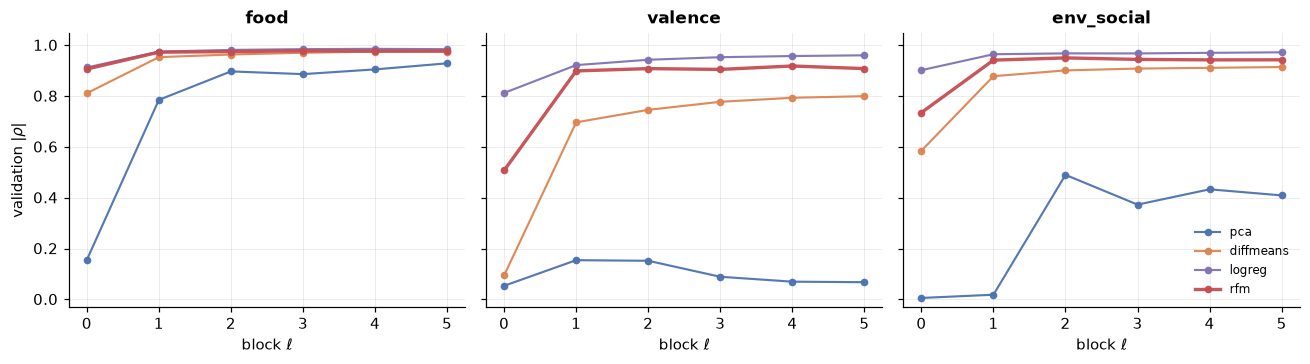

,food,valence,env_social
method,,,
pca,0.9288,0.1544,0.4900
diffmeans,0.9749,0.7995,0.9142
logreg,0.9857,0.9603,0.9721
rfm,0.9782,0.9183,0.9502


In [2]:
from rfm_guppy.baselines import extract_all_baseline_vectors

t0 = time.time()
base = {c: extract_all_baseline_vectors(acts[c]["train"], labels[c]["train"],
                                        acts[c]["val"],   labels[c]["val"]) for c in CONCEPTS}
print(f"three baselines × 3 concepts × 6 blocks in {time.time()-t0:.1f}s")

rho = {c: {m: base[c][m]["val_abs_rho"] for m in ["pca", "diffmeans", "logreg"]} for c in CONCEPTS}
for c in CONCEPTS:
    rho[c]["rfm"] = vecs[c]["val_abs_rho"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, c in zip(axes, CONCEPTS):
    for m in METHODS:
        ax.plot(range(6), rho[c][m], marker="o", ms=4,
                lw=2.2 if m == "rfm" else 1.4,
                color=METHOD_COLORS[m], label=m, alpha=0.95)
    ax.set_xlabel("block ℓ"); ax.set_title(c)
axes[0].set_ylabel(r"validation $|\rho|$"); axes[0].set_ylim(-0.03, 1.05)
axes[-1].legend(fontsize=8)
plt.tight_layout(); plt.show()

pd.DataFrame([{"method": m, **{c: f"{max(rho[c][m]):.4f}" for c in CONCEPTS}}
              for m in METHODS]).set_index("method")

**The separation the paper predicts does appear — against PCA, and only on the hard concept.**

On `food`, every method is above 0.92 and the ranking is a formality. On `valence` — the concept
notebook `01` showed this model represents weakly — PCA collapses to **0.15** while RFM reaches
0.92. On `env_social` PCA manages 0.49 against RFM's 0.95.

The reason is structural rather than incidental. PCA as implemented here takes the top direction
of *variance* in the positive-minus-negative difference matrix, and variance is not the same thing
as the class boundary: when the two classes differ subtly but each has plenty of internal spread,
the top principal component tracks the spread. DiffMeans and LogReg, like RFM, are supervised —
they optimise against the labels — and they stay much closer, though not uniformly:
DiffMeans still trails RFM on `valence` (0.799 against 0.918). In fact **LogReg edges
RFM out on all three concepts** by this measure (0.986/0.960/0.972 against 0.978/0.918/0.950),
which is the first hint of the conclusion this notebook arrives at.

### Do the four methods find the *same* direction?

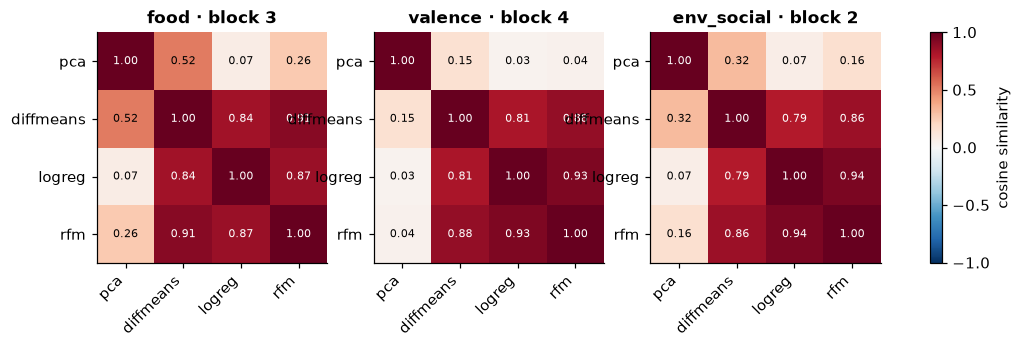

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4))
for ax, c in zip(axes, CONCEPTS):
    blk = int(np.argmax(vecs[c]["val_abs_rho"]))
    V = np.stack([base[c][m]["v_per_block"][blk] if m != "rfm"
                  else vecs[c]["v_per_block"][blk].astype(float) for m in METHODS])
    V = V / np.linalg.norm(V, axis=1, keepdims=True)
    Cm = V @ V.T
    im = ax.imshow(Cm, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(4), METHODS, rotation=45, ha="right")
    ax.set_yticks(range(4), METHODS); ax.grid(False)
    ax.set_title(f"{c} · block {blk}")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{Cm[i, j]:.2f}", ha="center", va="center", fontsize=7.5,
                    color="white" if abs(Cm[i, j]) > 0.6 else "black")
fig.colorbar(im, ax=axes, shrink=0.8, label="cosine similarity")
plt.show()

---
## 2 · Monitoring: does the cheaper direction detect the concept just as well?

Each method's per-block vectors become a 6-feature probe (`⟨a_ℓ − μ_ℓ, v_ℓ⟩` for each block),
trained on train, `C` selected on validation, scored by AUROC on test.

✓ baseline probes refitted here reproduce results/baselines_monitoring.json exactly


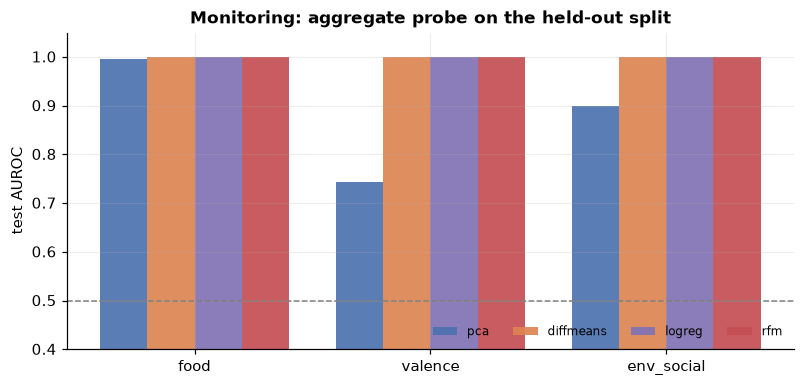

,food,valence,env_social,overall
method,,,,
pca,0.9947,0.7425,0.8992,0.8788
diffmeans,1.0000,1.0000,1.0000,1.0000
logreg,1.0000,1.0000,1.0000,1.0000
rfm,1.0000,1.0000,1.0000,1.0000


In [4]:
from rfm_guppy.baselines import baseline_monitoring_auroc

committed = load_result("baselines_monitoring.json")
mon = {c: {m: committed[c][m]["test_auroc"] for m in METHODS} for c in CONCEPTS}

# Reproducibility check: refit the three baseline probes here and confirm they land on the
# committed numbers before any of them is plotted.
for c in CONCEPTS:
    for m in ["pca", "diffmeans", "logreg"]:
        _, test_auroc = baseline_monitoring_auroc(
            acts[c]["train"], labels[c]["train"],
            acts[c]["val"],   labels[c]["val"],
            acts[c]["test"],  labels[c]["test"],
            v_per_block    = base[c][m]["v_per_block"],
            mean_per_block = base[c][m]["mean_per_block"],
        )
        assert abs(test_auroc - committed[c][m]["test_auroc"]) < 1e-9, \
            f"{c}/{m} diverged from results/baselines_monitoring.json"
print("\u2713 baseline probes refitted here reproduce results/baselines_monitoring.json exactly")

fig, ax = plt.subplots(figsize=(7.4, 3.6))
w, xs = 0.2, np.arange(len(CONCEPTS))
for i, m in enumerate(METHODS):
    ax.bar(xs + (i - 1.5) * w, [mon[c][m] for c in CONCEPTS], w,
           color=METHOD_COLORS[m], label=m, alpha=0.92)
ax.axhline(0.5, color="gray", ls="--", lw=1)
ax.set_xticks(xs, CONCEPTS); ax.set_ylim(0.4, 1.05)
ax.set_ylabel("test AUROC"); ax.set_title("Monitoring: aggregate probe on the held-out split")
ax.legend(ncol=4, fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

pd.DataFrame([{"method": m, **{c: f"{mon[c][m]:.4f}" for c in CONCEPTS},
               "overall": f"{np.mean([mon[c][m] for c in CONCEPTS]):.4f}"}
              for m in METHODS]).set_index("method")

### An asymmetry worth removing

That table is not quite a fair fight, and the original Phase 8 output says so in a footnote: the
**RFM row uses three eigenvectors per block (18 features), the baselines use one vector per block
(6 features)**. RFM is being given three times the probe capacity.

The control is cheap — rebuild the RFM probe from its top eigenvector only, exactly the way each
baseline is built — so let us just run it.

In [5]:
rows = []
for c in CONCEPTS:
    val_auroc, test_auroc = baseline_monitoring_auroc(
        acts[c]["train"], labels[c]["train"],
        acts[c]["val"],   labels[c]["val"],
        acts[c]["test"],  labels[c]["test"],
        v_per_block    = vecs[c]["v_per_block"].astype(float),
        mean_per_block = vecs[c]["input_mean"].astype(float),
    )
    rows.append({"concept": c,
                 "RFM, 3 eigvecs (18 feat)": f'{mon[c]["rfm"]:.4f}',
                 "RFM, top eigvec (6 feat)": f"{test_auroc:.4f}",
                 "DiffMeans (6 feat)":       f'{mon[c]["diffmeans"]:.4f}',
                 "LogReg (6 feat)":          f'{mon[c]["logreg"]:.4f}',
                 "PCA (6 feat)":             f'{mon[c]["pca"]:.4f}'})
display(Markdown("**Like-for-like monitoring comparison — one direction per block for every method**"))
pd.DataFrame(rows).set_index("concept")

**Like-for-like monitoring comparison — one direction per block for every method**

,"RFM, 3 eigvecs (18 feat)","RFM, top eigvec (6 feat)",DiffMeans (6 feat),LogReg (6 feat),PCA (6 feat)
concept,,,,,
food,1.0000,1.0000,1.0000,1.0000,0.9947
valence,1.0000,1.0000,1.0000,1.0000,0.7425
env_social,1.0000,1.0000,1.0000,1.0000,0.8992


Stripped to one direction per block, RFM still scores 1.000. The extra eigenvectors were not
carrying the result — but neither did removing them create any daylight between RFM, DiffMeans and
LogReg. All three supervised methods sit on the ceiling with or without the handicap.

---
## 3 · Steering, and a metric that gives up

The same comparison for steering: baseline vectors drive the perturbation, and the **RFM probe**
scores the outcome, so every method is measured with the same stick.

In [6]:
steer_b = load_result("baselines_steering.json")
rfm_ev  = {c: load_result(f"eval6_{c}.json") for c in CONCEPTS}

rows = []
for m in METHODS:
    row = {"method": m}
    for c in CONCEPTS:
        row[c] = (rfm_ev[c]["best_success_rate"] if m == "rfm"
                  else steer_b[c][m]["best_success_rate"])
    row["overall"] = np.mean([row[c] for c in CONCEPTS])
    rows.append(row)
display(Markdown("**Steering success rate (best over positive r)**"))
display(pd.DataFrame(rows).set_index("method").style.format("{:.3f}"))

# What the same metric says under *negative* steering.
neg = []
for m in ["pca", "diffmeans", "logreg"]:
    d = steer_b["food"][m]["results_per_r"]
    neg.append({"method": m, **{f"r={r}": f'{d[r]["mean_probe_score"]:.3f}'
                                for r in ["-2.0", "-1.0", "-0.5", "0.0", "0.5", "1.0", "2.0"]}})
neg.append({"method": "rfm", **{f"r={r}": f'{rfm_ev["food"]["eval_per_r"][r]["mean_probe_score"]:.3f}'
                                for r in ["-2.0", "-1.0", "-0.5", "0.0", "0.5", "1.0", "2.0"]}})
display(Markdown("**Mean probe score vs r on `food` — note the negative-r columns**"))
pd.DataFrame(neg).set_index("method")

**Steering success rate (best over positive r)**

,food,valence,env_social,overall
method,,,,
pca,1.000,1.000,1.000,1.000
diffmeans,1.000,1.000,1.000,1.000
logreg,1.000,1.000,1.000,1.000
rfm,1.000,1.000,1.000,1.000


**Mean probe score vs r on `food` — note the negative-r columns**

,r=-2.0,r=-1.0,r=-0.5,r=0.0,r=0.5,r=1.0,r=2.0
method,,,,,,,
pca,1.000,1.000,1.000,0.488,1.000,1.000,0.999
diffmeans,0.841,0.856,0.973,0.488,1.000,1.000,0.999
logreg,0.889,0.845,0.479,0.488,0.999,0.999,0.982
rfm,0.454,0.436,0.280,0.488,0.882,0.511,0.305


**All four methods score 1.000. That is a broken measurement, not a four-way tie.**

The second table shows why. Under **negative** steering — pushing the activations *away* from the
concept — the RFM probe still reports the concept as present for all three baselines: PCA scores
1.000 at `r = −2`, DiffMeans 0.841, LogReg 0.889, every one of them comfortably over the 0.5
success threshold. Those methods are credited with a "success" for steering in the wrong
direction, at both signs, which is how they reach 1.000 overall.

Only the RFM row behaves like a measurement: 0.454 at `r = −2` and 0.436 at `r = −1`, below
threshold, rising to 0.882 at `r = +0.5` before the model collapses and drags it back down. That
asymmetry is not a virtue of RFM so much as an artifact of the setup — the probe is built from the
RFM eigenbasis, so the sign convention only lines up for RFM, and the baselines are being scored
in a basis whose orientation they never agreed to.

A metric that cannot distinguish `+ε` from `−ε` for three of the four methods it is comparing
cannot rank them. The steering row of the Phase 8 comparison should be read as **uninformative**,
not as evidence of parity — and combined with notebook `02`'s finding that none of these
perturbations yields fluent text anyway, this is the weakest result in the project.

---
## 4 · The committed Phase 8 summary

In [7]:
with open(os.path.join(ROOT, "results", "baselines_comparison.md")) as f:
    display(Markdown(f.read()))

# Phase 8 — Baseline Comparison

## Concept Vector Quality: Val |Pearson| (best block)

| Method | food | valence | env_social |
|--------|------|---------|------------|
| pca        | 0.9288 | 0.1544 | 0.4900 |
| diffmeans  | 0.9749 | 0.7995 | 0.9142 |
| logreg     | 0.9857 | 0.9603 | 0.9721 |


## Monitoring AUROC Comparison

*(Aggregate probe; test split)*

| Method | food | valence | env_social | Overall |
|--------|------|---------|------------|---------|
| PCA        | 0.9947 | 0.7425 | 0.8992 | 0.8788 |
| DiffMeans  | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| LogReg     | 1.0000 | 1.0000 | 1.0000 | 1.0000 |
| RFM        | 1.0000 | 1.0000 | 1.0000 | 1.0000 |


## Steering Success-Rate Comparison

*(Best-over-positive-ε; probe-score > 0.5 OR lexicon hit)*

| Method | food | valence | env_social | Overall |
|--------|------|---------|------------|---------|
| PCA        | 1.000 | 1.000 | 1.000 | 1.000 |
| DiffMeans  | 1.000 | 1.000 | 1.000 | 1.000 |
| LogReg     | 1.000 | 1.000 | 1.000 | 1.000 |
| RFM        | 1.000 | 1.000 | 1.000 | 1.000 |


### Winner summary

- Best monitoring AUROC: **DiffMeans**
- Best steering success: **PCA**

*Note: RFM monitoring uses 3 eigenvectors per block (Phase 7); baselines use 1 vector per block.*  
*RFM steering uses vectors from 01_extract.py; success rates come from eval6 Phase 6 results.*  
*All methods evaluated on identical splits, identical ε sweeps, identical probe threshold (0.5).*


---
## What this phase established

| Claim under test | Verdict |
|---|---|
| RFM beats PCA | **Yes, clearly** — val `\|ρ\|` 0.92 vs 0.15 on `valence`, 0.95 vs 0.49 on `env_social`; monitoring 1.000 vs 0.879 overall |
| RFM beats DiffMeans and LogReg | **Not shown** — all three tie at AUROC 1.000, with or without the 18-vs-6 feature handicap removed |
| The steering comparison ranks the methods | **No** — the probe metric is sign-blind for the three baselines, so its 1.000s carry no information |
| RFM's extra machinery earned its cost here | **No** — DiffMeans is one subtraction and ties it at AUROC 1.000 on every concept, the only measure here that discriminates at all |

This is the outcome the paper's own reasoning predicts. RFM's advantage is supposed to show up on
concepts where the class boundary is *not* the direction of greatest variance and *not* a simple
mean shift — subtle, entangled, emergent properties in models large enough to have them. Three
in-domain topic-and-mood distinctions in an 8.7M-parameter fish chatbot are not that test, and
they were never going to be: everything supervised saturates.

The honest conclusion of the whole replication is therefore split in two. **The mechanism
transfers**: AGOP recovers linear concept directions at 8.7M parameters, those directions are
causal when written back into the stream, and they support a perfect linear read-out. **The
comparative claim does not get tested at all**, and demonstrating it needs what
[`results/REPORT.md`](../results/REPORT.md) identifies as the next step — a model ladder such as
Pythia 14M→12B, genuinely hard concepts, and an external judge that is not built from the same
eigenvectors as the thing it is judging.